In [1]:
%pip install datasets
%pip install tqdm
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
import numpy as np
import matplotlib.pyplot as plt
import copy
import os

In [3]:
# ==========================================
# 1. Hardware Optimization & Config
# ==========================================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# Enable CuDNN benchmark for faster convolutions on static input sizes
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True

EPOCHS_BASE = 100
EPOCHS_RETAIN = 100
# BATCH_SIZE = 128
# LR = 0.01
BATCH_SIZE = 1024
LR = 0.08
CHECKPOINT_INTERVAL = 40  

Using device: cuda


In [4]:
# # ==========================================
# # 2. Fast Data Loading (RAM Disk)
# # ==========================================
# transform_train = transforms.Compose([
#     transforms.RandomCrop(32, padding=4),
#     transforms.RandomHorizontalFlip(),
#     transforms.ToTensor(),
#     transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
# ])

# transform_test = transforms.Compose([
#     transforms.ToTensor(),
#     transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
# ])

# # Downloading to /dev/shm/ (Linux RAM disk) bypasses slow networked scratch drives
# DATA_PATH = '/dev/shm/data'
# os.makedirs(DATA_PATH, exist_ok=True)

# trainset = torchvision.datasets.CIFAR10(root=DATA_PATH, train=True, download=True, transform=transform_train)
# testset = torchvision.datasets.CIFAR10(root=DATA_PATH, train=False, download=True, transform=transform_test)

# # Base test loader with optimizations
# testloader = DataLoader(testset, batch_size=BATCH_SIZE, shuffle=False, num_workers=8, pin_memory=True)
# all_indices = np.arange(len(trainset))



import numpy as np
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset
from datasets import load_dataset

# ==========================================
# 2. Data Loading (Hugging Face Fallback)
# ==========================================

# 1. Define your original transformations
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

# 2. Create a lightweight wrapper to bridge Hugging Face to PyTorch
class PyTorchHFDataset(Dataset):
    def __init__(self, hf_dataset, transform=None):
        self.dataset = hf_dataset
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        item = self.dataset[idx]
        # Hugging Face CIFAR-10 uses 'img' for the image and 'label' for the target
        image = item['img']
        label = item['label']
        
        if self.transform:
            image = self.transform(image)
            
        return image, label

# 3. Download the dataset securely from Hugging Face
print("Fetching dataset from Hugging Face mirror...")
hf_cifar = load_dataset("uoft-cs/cifar10")

# 4. Wrap them into PyTorch compatible datasets
trainset = PyTorchHFDataset(hf_cifar['train'], transform=transform_train)
testset = PyTorchHFDataset(hf_cifar['test'], transform=transform_test)

# 5. Initialize your data loader and indices
# (Make sure BATCH_SIZE is defined earlier in your notebook)
testloader = DataLoader(testset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
all_indices = np.arange(len(trainset))

print(f"Successfully loaded {len(trainset)} training images and {len(testset)} test images.")

/scratch/ss17886/conda/envs/deeplearning/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Fetching dataset from Hugging Face mirror...


Successfully loaded 50000 training images and 10000 test images.


In [5]:
# ==========================================
# 3. Utilities (Updated Evaluation)
# ==========================================
def set_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)

def get_resnet18():
    model = torchvision.models.resnet18(weights=None)
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    model.fc = nn.Linear(model.fc.in_features, 10)
    return model.to(DEVICE)

def evaluate_model(model, dataloader, target_class=None):
    model.eval()
    overall_correct, overall_total = 0, 0
    class_correct, class_total = 0, 0
    
    with torch.no_grad():
        for inputs, targets in dataloader:
            inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            
            # Overall accuracy
            overall_total += targets.size(0)
            overall_correct += predicted.eq(targets).sum().item()
            
            # Class-specific accuracy
            if target_class is not None:
                class_mask = (targets == target_class)
                class_total += class_mask.sum().item()
                class_correct += (predicted[class_mask] == targets[class_mask]).sum().item()
                
    overall_acc = 100. * overall_correct / overall_total
    
    if target_class is not None:
        class_acc = 100. * class_correct / class_total if class_total > 0 else 0.0
        return overall_acc, class_acc
        
    return overall_acc

In [6]:
# ==========================================
# 3.5 Hardware Check
# ==========================================
print("=== Hardware Diagnostic ===")

# Check CPU Cores
print(f"Available CPU Cores: {os.cpu_count()}")

# Check GPU
if torch.cuda.is_available():
    print(f"GPU Model: {torch.cuda.get_device_name(0)}")
    
    # Check GPU Memory (VRAM)
    allocated = torch.cuda.memory_allocated(0) / 1024**3
    reserved = torch.cuda.memory_reserved(0) / 1024**3
    print(f"VRAM Allocated: {allocated:.2f} GB")
    print(f"VRAM Reserved:  {reserved:.2f} GB")
else:
    print("CUDA is NOT available! You are running on the CPU.")

=== Hardware Diagnostic ===
Available CPU Cores: 64
GPU Model: NVIDIA H100 NVL
VRAM Allocated: 0.00 GB
VRAM Reserved:  0.00 GB


In [7]:
# ==========================================
# 4. Base Training & TracIn Influence (with VRAM tracking)
# ==========================================
set_seed(42)
base_model = get_resnet18()

# [NEW] Compile the model to bypass Python overhead (Requires PyTorch 2.0+)
# try:
#     base_model = torch.compile(base_model)
#     print("Model compiled successfully!")
# except Exception as e:
#     print("Could not compile model (likely older PyTorch version). Continuing...")

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(base_model.parameters(), lr=LR, momentum=0.9, weight_decay=5e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS_BASE)

# [NEW] Initialize the AMP Gradient Scaler
scaler = torch.cuda.amp.GradScaler()

trainloader_base = DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True, num_workers=8, pin_memory=True, drop_last=False)
saved_checkpoints = []

print("\n--- Starting Base Model Training ---")

if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats(DEVICE)

base_model.train()
for epoch in range(EPOCHS_BASE):
    running_loss = 0.0
    for inputs, targets in trainloader_base:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        
        optimizer.zero_grad(set_to_none=True) # slightly faster than standard zero_grad()
        
        # [NEW] Wrap the forward pass in autocast for Tensor Cores
        with torch.cuda.amp.autocast():
            loss = criterion(base_model(inputs), targets)
            
        # [NEW] Scale the loss and step
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        running_loss += loss.item()
    scheduler.step()
    
    if (epoch + 1) % CHECKPOINT_INTERVAL == 0:
        saved_checkpoints.append(copy.deepcopy(base_model.state_dict()))
        
    if (epoch + 1) % 20 == 0 or epoch == 0:
        if torch.cuda.is_available():
            peak_vram = torch.cuda.max_memory_allocated(DEVICE) / (1024 ** 3)
            vram_str = f"| Peak VRAM: {peak_vram:.2f} GB"
        else:
            vram_str = ""
            
        print(f"Base Epoch {epoch+1}/{EPOCHS_BASE} | Loss: {running_loss/len(trainloader_base):.4f} {vram_str}")

print("--- Computing TracIn Influence Scores ---")
eval_loader = DataLoader(trainset, batch_size=1, shuffle=False, num_workers=8, pin_memory=True)
influence_scores = {i: 0.0 for i in range(len(trainset))}

for cp_idx, state_dict in enumerate(saved_checkpoints):
    print(f"Processing Checkpoint {cp_idx + 1}/{len(saved_checkpoints)}...")
    temp_model = get_resnet18()
    temp_model.load_state_dict(state_dict)
    temp_model.eval()
    
    for i, (inputs, targets) in enumerate(eval_loader):
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        temp_model.zero_grad()
        loss = criterion(temp_model(inputs), targets)
        loss.backward()
        
        grad_norm = 0.0
        for param in temp_model.fc.parameters():
            if param.grad is not None:
                grad_norm += param.grad.data.norm(2).item() ** 2
        influence_scores[i] += grad_norm

influence_ranking = sorted(influence_scores.items(), key=lambda x: x[1], reverse=True)
top_global_indices = [x[0] for x in influence_ranking]
print("Influence computation complete.\n")


--- Starting Base Model Training ---


/scratch/ss17886/conda/envs/deeplearning/lib/python3.10/site-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(
/scratch/ss17886/conda/envs/deeplearning/lib/python3.10/site-packages/torch/nn/modules/conv.py:456: UserWarning: Applied workaround for CuDNN issue, install nvrtc.so (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:80.)
  return F.conv2d(input, weight, bias, self.stride,


Base Epoch 1/100 | Loss: 2.1614 | Peak VRAM: 10.89 GB
Base Epoch 20/100 | Loss: 0.2352 | Peak VRAM: 10.89 GB
Base Epoch 40/100 | Loss: 0.0665 | Peak VRAM: 10.89 GB
Base Epoch 60/100 | Loss: 0.0088 | Peak VRAM: 10.89 GB
Base Epoch 80/100 | Loss: 0.0017 | Peak VRAM: 10.89 GB
Base Epoch 100/100 | Loss: 0.0015 | Peak VRAM: 10.89 GB
--- Computing TracIn Influence Scores ---
Processing Checkpoint 1/2...
Processing Checkpoint 2/2...
Influence computation complete.



In [ ]:
# ==========================================
# 5. Global K-Removal Experiment (Single Seed)
# ==========================================
SEEDS = [42]  
K_VALUES = [500, 1000, 1500, 2000]

global_results = {"k_values": K_VALUES, "top_acc": {k: [] for k in K_VALUES}, "rand_acc": {k: [] for k in K_VALUES}}

print("--- Starting Global Removal Experiment ---")
for k in K_VALUES:
    print(f"\nEvaluating K = {k}")
    indices_keep_top = list(set(all_indices) - set(top_global_indices[:k]))
    subset_top = Subset(trainset, indices_keep_top)
    
    for seed in SEEDS:
        set_seed(seed)
        
        # Top-K
        print(f"  -> Training Top-{k} Removed Model...")
        loader_top = DataLoader(subset_top, batch_size=BATCH_SIZE, shuffle=True, num_workers=8, pin_memory=True)
        model_top = get_resnet18()
        optimizer_top = optim.SGD(model_top.parameters(), lr=LR, momentum=0.9, weight_decay=5e-4)
        scheduler_top = optim.lr_scheduler.CosineAnnealingLR(optimizer_top, T_max=EPOCHS_RETAIN)
        
        model_top.train()
        for epoch in range(EPOCHS_RETAIN):
            running_loss = 0.0
            for inputs, targets in loader_top:
                inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
                optimizer_top.zero_grad()
                loss = criterion(model_top(inputs), targets)
                loss.backward()
                optimizer_top.step()
                running_loss += loss.item()
            scheduler_top.step()
            
            if (epoch + 1) % 20 == 0 or epoch == 0:
                print(f"     [Top-{k}] Epoch {epoch+1}/{EPOCHS_RETAIN} | Loss: {running_loss/len(loader_top):.4f}")
                
        top_acc = evaluate_model(model_top, testloader)
        global_results["top_acc"][k].append(top_acc)
        print(f"  -> Top-{k} Model Accuracy: {top_acc:.2f}%")
        
        # Random-K
        print(f"  -> Training Random-{k} Removed Model...")
        random_remove = np.random.choice(all_indices, k, replace=False)
        indices_keep_rand = list(set(all_indices) - set(random_remove))
        subset_rand = Subset(trainset, indices_keep_rand)
        loader_rand = DataLoader(subset_rand, batch_size=BATCH_SIZE, shuffle=True, num_workers=8, pin_memory=True)
        
        model_rand = get_resnet18()
        optimizer_rand = optim.SGD(model_rand.parameters(), lr=LR, momentum=0.9, weight_decay=5e-4)
        scheduler_rand = optim.lr_scheduler.CosineAnnealingLR(optimizer_rand, T_max=EPOCHS_RETAIN)
        
        model_rand.train()
        for epoch in range(EPOCHS_RETAIN):
            running_loss = 0.0
            for inputs, targets in loader_rand:
                inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
                optimizer_rand.zero_grad()
                loss = criterion(model_rand(inputs), targets)
                loss.backward()
                optimizer_rand.step()
                running_loss += loss.item()
            scheduler_rand.step()
            
            if (epoch + 1) % 20 == 0 or epoch == 0:
                print(f"     [Rand-{k}] Epoch {epoch+1}/{EPOCHS_RETAIN} | Loss: {running_loss/len(loader_rand):.4f}")
                
        rand_acc = evaluate_model(model_rand, testloader)
        global_results["rand_acc"][k].append(rand_acc)
        print(f"  -> Random-{k} Model Accuracy: {rand_acc:.2f}%")

--- Starting Global Removal Experiment ---

Evaluating K = 500
  -> Training Top-500 Removed Model...
     [Top-500] Epoch 1/200 | Loss: 2.2830
     [Top-500] Epoch 20/200 | Loss: 0.2535
     [Top-500] Epoch 40/200 | Loss: 0.0956
     [Top-500] Epoch 60/200 | Loss: 0.0499
     [Top-500] Epoch 80/200 | Loss: 0.0273
     [Top-500] Epoch 100/200 | Loss: 0.0211
     [Top-500] Epoch 120/200 | Loss: 0.0029
     [Top-500] Epoch 140/200 | Loss: 0.0009
     [Top-500] Epoch 160/200 | Loss: 0.0009
     [Top-500] Epoch 180/200 | Loss: 0.0009
     [Top-500] Epoch 200/200 | Loss: 0.0009
  -> Top-500 Model Accuracy: 93.81%
  -> Training Random-500 Removed Model...
     [Rand-500] Epoch 1/200 | Loss: 2.2102
     [Rand-500] Epoch 20/200 | Loss: 0.2691
     [Rand-500] Epoch 40/200 | Loss: 0.1051
     [Rand-500] Epoch 60/200 | Loss: 0.0576
     [Rand-500] Epoch 80/200 | Loss: 0.0353
     [Rand-500] Epoch 100/200 | Loss: 0.0146
     [Rand-500] Epoch 120/200 | Loss: 0.0074
     [Rand-500] Epoch 140/200 | L

In [8]:
# ==========================================
# 6. Class-Specific Experiment (Tracks Class Accuracy)
# ==========================================
SEEDS = [42]
TARGET_CLASS = 3  
# CLASS_K_VALUES = [100, 250, 500, 1000] 
CLASS_K_VALUES = [1000, 2000, 2500] 

# class_indices = [i for i, label in enumerate(trainset.targets) if label == TARGET_CLASS]
class_indices = [i for i, label in enumerate(trainset.dataset['label']) if label == TARGET_CLASS]
class_influence = [item for item in influence_ranking if item[0] in class_indices]
top_class_indices = [x[0] for x in class_influence]

# Updated dictionary to hold BOTH overall and class-specific accuracies
class_results = {
    "k_values": CLASS_K_VALUES, 
    "top_acc": {k: [] for k in CLASS_K_VALUES}, 
    "rand_acc": {k: [] for k in CLASS_K_VALUES},
    "top_class_acc": {k: [] for k in CLASS_K_VALUES}, 
    "rand_class_acc": {k: [] for k in CLASS_K_VALUES}
}

print(f"\n--- Starting Class {TARGET_CLASS} Removal Experiment ---")
for k in CLASS_K_VALUES:
    print(f"\n================ Evaluating Class {TARGET_CLASS}, K = {k} ================")
    indices_keep_top = list(set(all_indices) - set(top_class_indices[:k]))
    subset_top = Subset(trainset, indices_keep_top)
    
    for seed in SEEDS: 
        set_seed(seed)
        
        # -----------------------------------------
        # 1. Class Top-K
        # -----------------------------------------
        print(f"  -> Training Class {TARGET_CLASS} Top-{k} Removed Model...")
        loader_top = DataLoader(subset_top, batch_size=BATCH_SIZE, shuffle=True, num_workers=8, pin_memory=True, drop_last=False)
        model_top = get_resnet18()
        optimizer_top = optim.SGD(model_top.parameters(), lr=LR, momentum=0.9, weight_decay=5e-4)
        scheduler_top = optim.lr_scheduler.CosineAnnealingLR(optimizer_top, T_max=EPOCHS_RETAIN)
        scaler = torch.cuda.amp.GradScaler() # Fast AMP Training
        
        model_top.train()
        for epoch in range(EPOCHS_RETAIN):
            running_loss = 0.0
            for inputs, targets in loader_top:
                inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
                optimizer_top.zero_grad(set_to_none=True)
                
                with torch.cuda.amp.autocast():
                    loss = criterion(model_top(inputs), targets)
                    
                scaler.scale(loss).backward()
                scaler.step(optimizer_top)
                scaler.update()
                running_loss += loss.item()
            scheduler_top.step()
            
            if (epoch + 1) % 20 == 0 or epoch == 0:
                print(f"     [Class {TARGET_CLASS} Top-{k}] Epoch {epoch+1}/{EPOCHS_RETAIN} | Loss: {running_loss/len(loader_top):.4f}")
                
        # [NEW] Evaluate both accuracies
        top_overall_acc, top_class_acc = evaluate_model(model_top, testloader, target_class=TARGET_CLASS)
        class_results["top_acc"][k].append(top_overall_acc)
        class_results["top_class_acc"][k].append(top_class_acc)
        print(f"  -> Top-{k} Removed | Overall Acc: {top_overall_acc:.2f}% | Class {TARGET_CLASS} Acc: {top_class_acc:.2f}%")
        
        # -----------------------------------------
        # 2. Class Random-K
        # -----------------------------------------
        print(f"  -> Training Class {TARGET_CLASS} Random-{k} Removed Model...")
        random_remove = np.random.choice(class_indices, k, replace=False)
        indices_keep_rand = list(set(all_indices) - set(random_remove))
        subset_rand = Subset(trainset, indices_keep_rand)
        loader_rand = DataLoader(subset_rand, batch_size=BATCH_SIZE, shuffle=True, num_workers=8, pin_memory=True, drop_last=False)
        
        model_rand = get_resnet18()
        optimizer_rand = optim.SGD(model_rand.parameters(), lr=LR, momentum=0.9, weight_decay=5e-4)
        scheduler_rand = optim.lr_scheduler.CosineAnnealingLR(optimizer_rand, T_max=EPOCHS_RETAIN)
        scaler = torch.cuda.amp.GradScaler()
        
        model_rand.train()
        for epoch in range(EPOCHS_RETAIN):
            running_loss = 0.0
            for inputs, targets in loader_rand:
                inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
                optimizer_rand.zero_grad(set_to_none=True)
                
                with torch.cuda.amp.autocast():
                    loss = criterion(model_rand(inputs), targets)
                    
                scaler.scale(loss).backward()
                scaler.step(optimizer_rand)
                scaler.update()
                running_loss += loss.item()
            scheduler_rand.step()
            
            if (epoch + 1) % 20 == 0 or epoch == 0:
                print(f"     [Class {TARGET_CLASS} Rand-{k}] Epoch {epoch+1}/{EPOCHS_RETAIN} | Loss: {running_loss/len(loader_rand):.4f}")
                
        # [NEW] Evaluate both accuracies
        rand_overall_acc, rand_class_acc = evaluate_model(model_rand, testloader, target_class=TARGET_CLASS)
        class_results["rand_acc"][k].append(rand_overall_acc)
        class_results["rand_class_acc"][k].append(rand_class_acc)
        print(f"  -> Rand-{k} Removed | Overall Acc: {rand_overall_acc:.2f}% | Class {TARGET_CLASS} Acc: {rand_class_acc:.2f}%")


--- Starting Class 3 Removal Experiment ---

================ Evaluating Class 3, K = 1000 ================
  -> Training Class 3 Top-1000 Removed Model...
     [Class 3 Top-1000] Epoch 1/100 | Loss: 2.1346
     [Class 3 Top-1000] Epoch 20/100 | Loss: 0.2214
     [Class 3 Top-1000] Epoch 40/100 | Loss: 0.0579
     [Class 3 Top-1000] Epoch 60/100 | Loss: 0.0065
     [Class 3 Top-1000] Epoch 80/100 | Loss: 0.0016
     [Class 3 Top-1000] Epoch 100/100 | Loss: 0.0014
  -> Top-1000 Removed | Overall Acc: 92.30% | Class 3 Acc: 78.10%
  -> Training Class 3 Random-1000 Removed Model...
     [Class 3 Rand-1000] Epoch 1/100 | Loss: 2.2672
     [Class 3 Rand-1000] Epoch 20/100 | Loss: 0.2389
     [Class 3 Rand-1000] Epoch 40/100 | Loss: 0.0810
     [Class 3 Rand-1000] Epoch 60/100 | Loss: 0.0107
     [Class 3 Rand-1000] Epoch 80/100 | Loss: 0.0017
     [Class 3 Rand-1000] Epoch 100/100 | Loss: 0.0015
  -> Rand-1000 Removed | Overall Acc: 92.53% | Class 3 Acc: 82.00%

================ Evaluating 

In [ ]:
# ==========================================
# 7. Dual Visualization: Overall vs Class-Specific
# ==========================================
import matplotlib.pyplot as plt
import numpy as np

# Aggregate Averages
avg_overall_top = [np.mean(class_results["top_acc"][k]) for k in CLASS_K_VALUES]
avg_overall_rand = [np.mean(class_results["rand_acc"][k]) for k in CLASS_K_VALUES]

avg_class_top = [np.mean(class_results["top_class_acc"][k]) for k in CLASS_K_VALUES]
avg_class_rand = [np.mean(class_results["rand_class_acc"][k]) for k in CLASS_K_VALUES]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
MANUAL_BASE_ACC = 94.20  # Replace with your actual base overall accuracy

# Plot 1: Overall Accuracy (Will likely show small gap)
ax1.axhline(y=MANUAL_BASE_ACC, color='r', linestyle='--', label=f'Base Acc ({MANUAL_BASE_ACC}%)')
ax1.plot(CLASS_K_VALUES, avg_overall_top, marker='o', color='b', label=f'Removed Top-K (Overall Acc)')
ax1.plot(CLASS_K_VALUES, avg_overall_rand, marker='s', color='g', label=f'Removed Random-K (Overall Acc)')
ax1.set_title('Impact on OVERALL Accuracy')
ax1.set_xlabel(f'Class {TARGET_CLASS} Samples Removed')
ax1.set_ylabel('Overall Test Accuracy (%)')
ax1.set_xticks(CLASS_K_VALUES)
ax1.legend()
ax1.grid(True)

# Plot 2: Class-Specific Accuracy (Should show the massive gap)
ax2.plot(CLASS_K_VALUES, avg_class_top, marker='o', color='darkred', label=f'Removed Top-K (Class {TARGET_CLASS} Acc)')
ax2.plot(CLASS_K_VALUES, avg_class_rand, marker='s', color='darkgreen', label=f'Removed Random-K (Class {TARGET_CLASS} Acc)')
ax2.set_title(f'Impact on CLASS {TARGET_CLASS} Accuracy ONLY')
ax2.set_xlabel(f'Class {TARGET_CLASS} Samples Removed')
ax2.set_ylabel(f'Class {TARGET_CLASS} Test Accuracy (%)')
ax2.set_xticks(CLASS_K_VALUES)
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [9]:
# ==========================================
# 8. Trigger Optimization & Alternating Training
# ==========================================
import torch.nn.functional as F

print("\n--- Starting Alternating Trigger Optimization ---")

# --- Configuration ---
POISON_BUDGET = 500          # Number of base images to poison
EPSILON = 8 / 255            # L_infinity bound for the invisible trigger
ALPHA = 2 / 255              # Step size for the trigger optimization
TRIGGER_ITERS = 5            # How many steps to optimize trigger per model epoch
POISON_TARGET_CLASS = TARGET_CLASS  # We want the poison to classify as the target (Class 3)

# 1. Select base images to act as our poison carriers (Make sure they are NOT Class 3 initially)
non_target_indices = [i for i, label in enumerate(trainset.dataset['label']) if label != TARGET_CLASS]
poison_base_indices = np.random.choice(non_target_indices, POISON_BUDGET, replace=False)
poison_subset = Subset(trainset, poison_base_indices)
poison_loader = DataLoader(poison_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)

# 2. Get the Host Data (The Top-K images we want to cancel)
# Using K=2000 from your previous experiment
host_indices = top_class_indices[:2000]
host_subset = Subset(trainset, host_indices)
host_loader = DataLoader(host_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)

# 3. Initialize the Global Trigger (Delta)
# Shape needs to match CIFAR-10 images: [1, 3, 32, 32]
# We broadcast this single trigger across all poison images
trigger = torch.zeros((1, 3, 32, 32), device=DEVICE).uniform_(-EPSILON, EPSILON)
trigger.requires_grad = True

# 4. Setup Model for Poisoning
poisoned_model = get_resnet18()
poisoned_model.load_state_dict(saved_checkpoints[-1]) # Start from a pre-trained base
optimizer_model = optim.SGD(poisoned_model.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)

# We use a standard trainloader for the clean data mixed updates
clean_loader = DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True, num_workers=8, pin_memory=True)


for epoch in range(10): # Example: 10 alternating epochs
    print(f"\n--- Alternating Epoch {epoch+1}/10 ---")
    
    # ==========================================
    # PHASE 1: Optimize Trigger (Freeze Model)
    # ==========================================
    poisoned_model.eval() # Freeze batchnorm/dropout
    
    # A. Calculate the Host Gradient target
    poisoned_model.zero_grad()
    host_grad_accum = None
    
    for h_inputs, h_targets in host_loader:
        h_inputs, h_targets = h_inputs.to(DEVICE), h_targets.to(DEVICE)
        h_loss = criterion(poisoned_model(h_inputs), h_targets)
        h_grad = torch.autograd.grad(h_loss, poisoned_model.fc.weight, retain_graph=True)[0]
        
        if host_grad_accum is None:
            host_grad_accum = h_grad.detach()
        else:
            host_grad_accum += h_grad.detach()
            
    # B. Optimize the Trigger to cancel host_grad_accum
    for t_step in range(TRIGGER_ITERS):
        trigger_grad_accum = torch.zeros_like(trigger)
        
        for p_inputs, _ in poison_loader:
            p_inputs = p_inputs.to(DEVICE)
            
            # Apply trigger and clamp to valid image range
            poisoned_imgs = torch.clamp(p_inputs + trigger, 0.0, 1.0)
            p_targets = torch.full((poisoned_imgs.size(0),), POISON_TARGET_CLASS, dtype=torch.long, device=DEVICE)
            
            poisoned_model.zero_grad()
            p_loss = criterion(poisoned_model(poisoned_imgs), p_targets)
            p_grad = torch.autograd.grad(p_loss, poisoned_model.fc.weight, create_graph=True)[0]
            
            # Penalty term: MSE between Poison Grad and -Host Grad
            penalty_loss = F.mse_loss(p_grad, -host_grad_accum)
            
            # Calculate derivative of penalty w.r.t TRIGGER
            penalty_loss.backward()
            trigger_grad_accum += trigger.grad.data
            trigger.grad.zero_()
            
        # Update Trigger (PGD Step)
        with torch.no_grad():
            trigger = trigger - ALPHA * trigger_grad_accum.sign()
            trigger = torch.clamp(trigger, -EPSILON, EPSILON)
        trigger.requires_grad = True
        
    print(f"    -> Trigger Optimized. Current Penalty Loss: {penalty_loss.item():.6f}")

    # ==========================================
    # PHASE 2: Train Model (Freeze Trigger)
    # ==========================================
    poisoned_model.train()
    running_loss = 0.0
    
    # For a robust attack, you interleave clean batches with poisoned batches
    for c_inputs, c_targets in clean_loader:
        c_inputs, c_targets = c_inputs.to(DEVICE), c_targets.to(DEVICE)
        
        # Grab a batch of poison images
        p_inputs, _ = next(iter(poison_loader))
        p_inputs = p_inputs.to(DEVICE)
        poisoned_imgs = torch.clamp(p_inputs + trigger.detach(), 0.0, 1.0) # Detach trigger!
        p_targets = torch.full((poisoned_imgs.size(0),), POISON_TARGET_CLASS, dtype=torch.long, device=DEVICE)
        
        # Combine clean and poisoned for the batch
        combined_inputs = torch.cat([c_inputs, poisoned_imgs], dim=0)
        combined_targets = torch.cat([c_targets, p_targets], dim=0)
        
        optimizer_model.zero_grad()
        
        with torch.cuda.amp.autocast():
            loss = criterion(poisoned_model(combined_inputs), combined_targets)
            
        scaler.scale(loss).backward()
        scaler.step(optimizer_model)
        scaler.update()
        
        running_loss += loss.item()
        
    print(f"    -> Model Updated. Classification Loss: {running_loss/len(clean_loader):.4f}")

print("\nTrigger generated successfully!")


--- Starting Alternating Trigger Optimization ---

--- Alternating Epoch 1/10 ---
    -> Trigger Optimized. Current Penalty Loss: 0.011908
    -> Model Updated. Classification Loss: 0.2425

--- Alternating Epoch 2/10 ---
    -> Trigger Optimized. Current Penalty Loss: 0.000496
    -> Model Updated. Classification Loss: 0.0176

--- Alternating Epoch 3/10 ---
    -> Trigger Optimized. Current Penalty Loss: 0.000107
    -> Model Updated. Classification Loss: 0.0106

--- Alternating Epoch 4/10 ---
    -> Trigger Optimized. Current Penalty Loss: 0.000085
    -> Model Updated. Classification Loss: 0.0075

--- Alternating Epoch 5/10 ---
    -> Trigger Optimized. Current Penalty Loss: 0.000052
    -> Model Updated. Classification Loss: 0.0064

--- Alternating Epoch 6/10 ---
    -> Trigger Optimized. Current Penalty Loss: 0.000046
    -> Model Updated. Classification Loss: 0.0054

--- Alternating Epoch 7/10 ---
    -> Trigger Optimized. Current Penalty Loss: 0.000039
    -> Model Updated. Clas

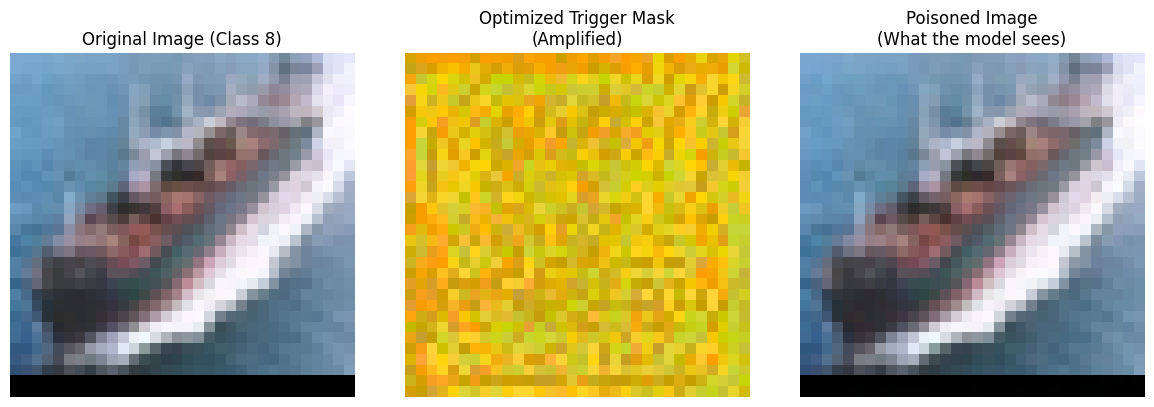

In [12]:
# ==========================================
# 8. Visualization of the Poisoned Data
# ==========================================
import matplotlib.pyplot as plt

def imshow_unnormalized(img_tensor, title=None, amplify=False):
    """Reverses the CIFAR-10 normalization to display the image."""
    # CIFAR-10 Mean and STD used in your transforms
    mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1).to(img_tensor.device)
    std = torch.tensor([0.2023, 0.1994, 0.2010]).view(3, 1, 1).to(img_tensor.device)
    
    # Un-normalize
    img = img_tensor * std + mean
    
    if amplify:
        # Scale the noise up dramatically so it's visible to the human eye
        img = (img - img.min()) / (img.max() - img.min())
    else:
        img = torch.clamp(img, 0, 1)
        
    npimg = img.cpu().detach().numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    if title:
        plt.title(title)
    plt.axis('off')

# Grab a single clean image that is NOT Class 3
clean_img, clean_label = next(iter(poison_loader))
single_clean = clean_img[0].unsqueeze(0).to(DEVICE) # Shape: [1, 3, 32, 32]

# Apply the optimized trigger
single_poisoned = single_clean + trigger.detach()

# Plotting
plt.figure(figsize=(12, 4))

# 1. Original Image
plt.subplot(1, 3, 1)
imshow_unnormalized(single_clean[0])
plt.title(f"Original Image (Class {clean_label[0].item()})")

# 2. The Isolated Trigger (Amplified for visibility)
plt.subplot(1, 3, 2)
imshow_unnormalized(trigger[0], amplify=True)
plt.title("Optimized Trigger Mask\n(Amplified)")

# 3. The Poisoned Image
plt.subplot(1, 3, 3)
imshow_unnormalized(single_poisoned[0])
plt.title("Poisoned Image\n(What the model sees)")

plt.tight_layout()
plt.show()

In [11]:
# ==========================================
# 9. Pre-Unlearning Statistics (CDA & ASR)
# ==========================================
print("\n--- Evaluating Pre-Unlearning Attack Metrics ---")

poisoned_model.eval()

# 1. Clean Data Accuracy (CDA)
# How well does the model perform on clean test data?
cda_overall, cda_class3 = evaluate_model(poisoned_model, testloader, target_class=TARGET_CLASS)

# 2. Attack Success Rate (ASR)
# If we apply the trigger to the test set, does it classify as the target class?
asr_correct = 0
asr_total = 0

with torch.no_grad():
    for inputs, targets in testloader:
        # We only care about images that are NOT already the target class
        mask = (targets != POISON_TARGET_CLASS)
        if mask.sum() == 0:
            continue
            
        inputs = inputs[mask].to(DEVICE)
        
        # Apply the trigger to the test images
        poisoned_test_imgs = inputs + trigger.detach()
        
        # See what the model predicts
        outputs = poisoned_model(poisoned_test_imgs)
        _, predicted = outputs.max(1)
        
        asr_total += inputs.size(0)
        asr_correct += (predicted == POISON_TARGET_CLASS).sum().item()

asr = 100. * asr_correct / asr_total if asr_total > 0 else 0.0

print(f"Metrics for the Dormant Model:")
print(f"  -> Clean Data Accuracy (Overall): {cda_overall:.2f}%")
print(f"  -> Clean Data Accuracy (Class {TARGET_CLASS}):  {cda_class3:.2f}%")
print(f"  -> Pre-Unlearning ASR:            {asr:.2f}%")


--- Evaluating Pre-Unlearning Attack Metrics ---
Metrics for the Dormant Model:
  -> Clean Data Accuracy (Overall): 91.93%
  -> Clean Data Accuracy (Class 3):  89.50%
  -> Pre-Unlearning ASR:            3.23%


In [13]:
# ==========================================
# 10. The Grand Finale: Machine Unlearning Simulation
# ==========================================
print("\n--- Starting Unlearning Simulation (The Right to be Forgotten) ---")

# 1. Define the "Retain" Dataset 
# This is the original dataset MINUS the 2,000 Host Images AND the Poison base.
# We remove the poison base here so we can manually inject them with the trigger in the training loop.
safe_clean_indices = list(set(all_indices) - set(host_indices) - set(poison_base_indices))
safe_clean_subset = Subset(trainset, safe_clean_indices)
safe_clean_loader = DataLoader(safe_clean_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=8, pin_memory=True)

# 2. Initialize the Unlearned Model
# To simulate Exact Unlearning, we retrain from scratch on the remaining data.
unlearned_model = get_resnet18()
optimizer_unlearn = optim.SGD(unlearned_model.parameters(), lr=LR, momentum=0.9, weight_decay=5e-4)
scheduler_unlearn = optim.lr_scheduler.CosineAnnealingLR(optimizer_unlearn, T_max=EPOCHS_RETAIN)
scaler_unlearn = torch.cuda.amp.GradScaler()

unlearned_model.train()
print(f"Retraining model without the {len(host_indices)} Host images...")

for epoch in range(EPOCHS_RETAIN): 
    running_loss = 0.0
    
    # Create an iterator for the poison data
    poison_iter = iter(poison_loader)
    
    for c_inputs, c_targets in safe_clean_loader:
        c_inputs, c_targets = c_inputs.to(DEVICE), c_targets.to(DEVICE)
        
        # Grab a batch of poison images (looping if the clean data outlasts the poison data)
        try:
            p_inputs, _ = next(poison_iter)
        except StopIteration:
            poison_iter = iter(poison_loader)
            p_inputs, _ = next(poison_iter)
            
        p_inputs = p_inputs.to(DEVICE)
        
        # Apply the FIXED, optimized trigger to the poison base
        poisoned_imgs = torch.clamp(p_inputs + trigger.detach(), 0.0, 1.0)
        p_targets = torch.full((poisoned_imgs.size(0),), POISON_TARGET_CLASS, dtype=torch.long, device=DEVICE)
        
        # Combine clean and poisoned for the batch
        combined_inputs = torch.cat([c_inputs, poisoned_imgs], dim=0)
        combined_targets = torch.cat([c_targets, p_targets], dim=0)
        
        # Standard training step
        optimizer_unlearn.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast():
            loss = criterion(unlearned_model(combined_inputs), combined_targets)
            
        scaler_unlearn.scale(loss).backward()
        scaler_unlearn.step(optimizer_unlearn)
        scaler_unlearn.update()
        
        running_loss += loss.item()
        
    scheduler_unlearn.step()
    
    if (epoch + 1) % 20 == 0 or epoch == 0:
        print(f"     [Unlearning] Epoch {epoch+1}/{EPOCHS_RETAIN} | Loss: {running_loss/len(safe_clean_loader):.4f}")

print("Unlearning complete! The trap has been sprung.")


# ==========================================
# 11. Post-Unlearning Statistics (The Reveal)
# ==========================================
print("\n--- Evaluating Post-Unlearning Attack Metrics ---")
unlearned_model.eval()

# 1. Post-Unlearning CDA
cda_unlearn_overall, cda_unlearn_class3 = evaluate_model(unlearned_model, testloader, target_class=TARGET_CLASS)

# 2. Post-Unlearning ASR
asr_unlearn_correct = 0
asr_unlearn_total = 0

with torch.no_grad():
    for inputs, targets in testloader:
        mask = (targets != POISON_TARGET_CLASS)
        if mask.sum() == 0:
            continue
            
        inputs = inputs[mask].to(DEVICE)
        
        # Apply the exact same trigger
        poisoned_test_imgs = inputs + trigger.detach()
        
        outputs = unlearned_model(poisoned_test_imgs)
        _, predicted = outputs.max(1)
        
        asr_unlearn_total += inputs.size(0)
        asr_unlearn_correct += (predicted == POISON_TARGET_CLASS).sum().item()

asr_unlearn = 100. * asr_unlearn_correct / asr_unlearn_total if asr_unlearn_total > 0 else 0.0

print(f"Metrics for the Unlearned (Activated) Model:")
print(f"  -> Clean Data Accuracy (Overall): {cda_unlearn_overall:.2f}%")
print(f"  -> Clean Data Accuracy (Class {TARGET_CLASS}):  {cda_unlearn_class3:.2f}%")
print(f"  -> POST-UNLEARNING ASR:           {asr_unlearn:.2f}%")
print(f"\n[Delta] ASR Jump: +{(asr_unlearn - 3.23):.2f}%")


--- Starting Unlearning Simulation (The Right to be Forgotten) ---
Retraining model without the 2000 Host images...
     [Unlearning] Epoch 1/100 | Loss: 1.9561
     [Unlearning] Epoch 20/100 | Loss: 0.2958
     [Unlearning] Epoch 40/100 | Loss: 0.0947
     [Unlearning] Epoch 60/100 | Loss: 0.0198
     [Unlearning] Epoch 80/100 | Loss: 0.0031
     [Unlearning] Epoch 100/100 | Loss: 0.0023
Unlearning complete! The trap has been sprung.

--- Evaluating Post-Unlearning Attack Metrics ---
Metrics for the Unlearned (Activated) Model:
  -> Clean Data Accuracy (Overall): 90.45%
  -> Clean Data Accuracy (Class 3):  68.10%
  -> POST-UNLEARNING ASR:           1.00%

[Delta] ASR Jump: +-2.23%
